# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [1]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
import timm
import os
import random
import joblib
import time, torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_auc_score
import cv2
import albumentations as A

import sys
sys.path.append("../utils")
from utils import (create_balanced_split, 
                   ISIC_Multimodal_Dataset, 
                   get_best_metadata, 
                   MetadataProcessor,
                   AdvancedHairAugmentation, 
                   Microscope,
                   make_sampler_weights,
                   TrainableModule, 
                   remove_last_layer,   
                   plot_analisis,
                   plot_stats)

# configure all:
class config:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_dir = Path("../data")
    models_dir = Path("../models")
    utils_dir = Path("../utils")
    submission_dir = Path("../submission")
    train_meta_csv = data_dir / "train-metadata.csv"
    test_meta_csv = data_dir / "test-metadata.csv"
    train_hdf5 = data_dir / "train-image.hdf5"
    test_hdf5 = data_dir / "test-image.hdf5"
    meta_procesor = utils_dir / "metadata_processor.pkl"
    metamodel_path = utils_dir / "metamodel.plk"
    ensemble_train_csv = utils_dir / "ensemble_train.csv"
    hairs_path = utils_dir / "hairs"
    lr = 1e5
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225],
    seed = 42
    image_size = 224
    epochs = 50
    batch_size = 16
    num_imgs_epoch = 3000
    target_epoch_proportion = 0.50
    BCE_loss_pos_weight = 1
    ratio_neg_pos = 25
    val_split = 0.2             # of train
    num_folds = 5
    num_feat = 0                # 0 = use all
    fine_tuning_batch = 90      # batch to train ensemble models
    val_freq = 5                # frequency of validation analisis
    attention_dim = 256         # dimension of trained attention ensemble
    unfreeze_schedule = [
        (5, 0.2),   # in epoch 5, 20%
        (40, 0.5),  # in epoch 30, 50%
        # (65, 0.75), # in epoch 65, 75%
    ]

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(config.seed)

/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and analyze the data

Because of the extreme class imbalance in the ISIC dataset (≈0.01% malignant vs. 99.99% benign), we apply two complementary strategies.  
First, we limit the number of benign samples by enforcing a controlled ratio of **25 benign lesions per malignant lesion** during training.  
Second, we apply an extensive yet medically appropriate **augmentation pipeline** to increase the effective diversity of malignant samples and reduce overfitting.

Below is a summary of the augmentation strategy used.

---

## Data Augmentation for Skin Lesion Classification (ISIC)

To improve the robustness of our multimodal classifier, we apply a set of **recommended and dermatology-consistent augmentations**, inspired by prior work on dermoscopic augmentation. In particular, our use of `AdvancedHairAugmentation` and `Microscope` artifacts was borrowed from the approach of GreatGameDota/SIIM-ISIC-Melanoma-Classification. :contentReference[oaicite:2]{index=2}

These transformations simulate realistic sources of variability such as camera angle, zoom, lighting, dermoscopic artifacts, and partial occlusions.

### 🔧 Summary of the Training Augmentation Pipeline

1. **Geometric Transformations (OneOf: ShiftScaleRotate / Affine / Perspective)**  
   A single transformation is chosen at random:
   - **ShiftScaleRotate**: small shifts, scaling (±15%), and rotations (±80°).  
   - **Affine (shear)**: simulates slight camera tilt.  
   - **Perspective**: mimics viewpoint variation.  
   **Purpose:** models acquisition differences across dermatoscopes while preserving lesion morphology.

2. **Horizontal & Vertical Flip (p=0.5 each)**  
   **Purpose:** lesions have no fixed orientation; flipping increases spatial variability safely.

3. **Resize to fixed resolution**  
   Ensures all images match the model input size.

4. **AdvancedHairAugmentation (p=0.5)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds realistic synthetic hairs over the image.  
   **Purpose:** increases robustness to one of the most common dermoscopic artifacts (hairs).

5. **RandomBrightnessContrast**  
   **Purpose:** simulates differences in lighting conditions, camera exposure, and skin tone variability.

6. **CoarseDropout (1–8 holes, up to 25% area)**  
   Randomly removes patches of the image.  
   **Purpose:** simulates partial occlusions (e.g. ruler marks, bubbles, ink, gel, hair clusters) and improves robustness.

7. **Microscope Effect (p=0.1)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds subtle lens or artefact-like distortions to simulate variability across dermatoscopic devices.  
   **Purpose:** increases generalization frente a variaciones de dispositivo o iluminación.

8. **Normalize (mean=0, std=1)**  
   Standard normalization for stable training.

### Validation Transformations

- **Resize** to input size  
- **Normalize** (mean=0, std=1)  

No augmentation is applied at validation time in order to evaluate performance on unaltered data.

---

## Scientific Support

These transformations are compatible with recommended augmentation practices in biomedical imaging. In particular, hair-artifact simulation and occlusion–robust augmentation han sido utilizados con éxito en pipelines para clasificación de melanoma (ver GreatGameDota/SIIM-ISIC-Melanoma-Classification).  
Además, trabajos como Towards Better Dermoscopic Image Feature Representation Learning for Melanoma Classification destacan que la presencia de artefactos (pelo, marcas, iluminación variable) representa un reto real en imágenes dermatoscópicas, y que estrategias como augmentación con oclusiones o ruido son útiles para mejorar la generalización. :contentReference[oaicite:4]{index=4}

---

Together, this augmentation pipeline improves generalization, reduces overfitting, and compensates for the scarcity of malignant samples in the dataset.


In [2]:
train_transform = A.Compose([
    A.OneOf([
        A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=80, shift_limit=0.1,
                           border_mode=cv2.BORDER_REPLICATE, p=0.5),
        A.Affine(shear=20, p=0.5),  # 'mode' eliminado
        A.Perspective(p=0.5),
    ], p=0.5),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Resize(config.image_size, config.image_size),

    AdvancedHairAugmentation(hairs=10, hairs_folder=config.hairs_path, p=0.5),
    A.RandomBrightnessContrast(),

    # CoarseDropout nuevo: usa num_holes, max_height, max_width
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(0.1, 0.25),
                    hole_width_range=(0.1, 0.25), 
                    fill=0, p=0.3),
    Microscope(p=0.1),

    # Normalize nuevo: no usar always_apply
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

val_transform = A.Compose([
    A.Resize(config.image_size, config.image_size),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:436: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


## Dataset analisis

In [3]:
# 1º Create a split of train and validation balanced
# we dont need all the images
train_df, val_df, df_balanced = create_balanced_split(
    config.train_meta_csv,
    neg_multiplier=config.ratio_neg_pos,      # conservative ratio of 25:1 
    val_frac=config.val_split            # split a 20% of train to validation
)

test_df = pd.read_csv(config.test_meta_csv, low_memory=False)

# 2º Run the metadata processor
if Path(config.meta_procesor).exists():
    metadata_processor =joblib.load(config.meta_procesor)
else:
    best_features = get_best_metadata(train_df, test_df, num_feat=config.num_feat, verbose=True)
    metadata_processor = MetadataProcessor(best_features)
    metadata_processor.fit(pd.read_csv(config.train_meta_csv))
    joblib.dump(metadata_processor, config.meta_procesor)



train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=train_df,
    image_transform=train_transform,
    metadata_processor=metadata_processor
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=val_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.test_hdf5,
    metadata_df=test_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:143: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 8575

Balanced dataset size: 8918
target
0    8575
1     343
Name: count, dtype: int64


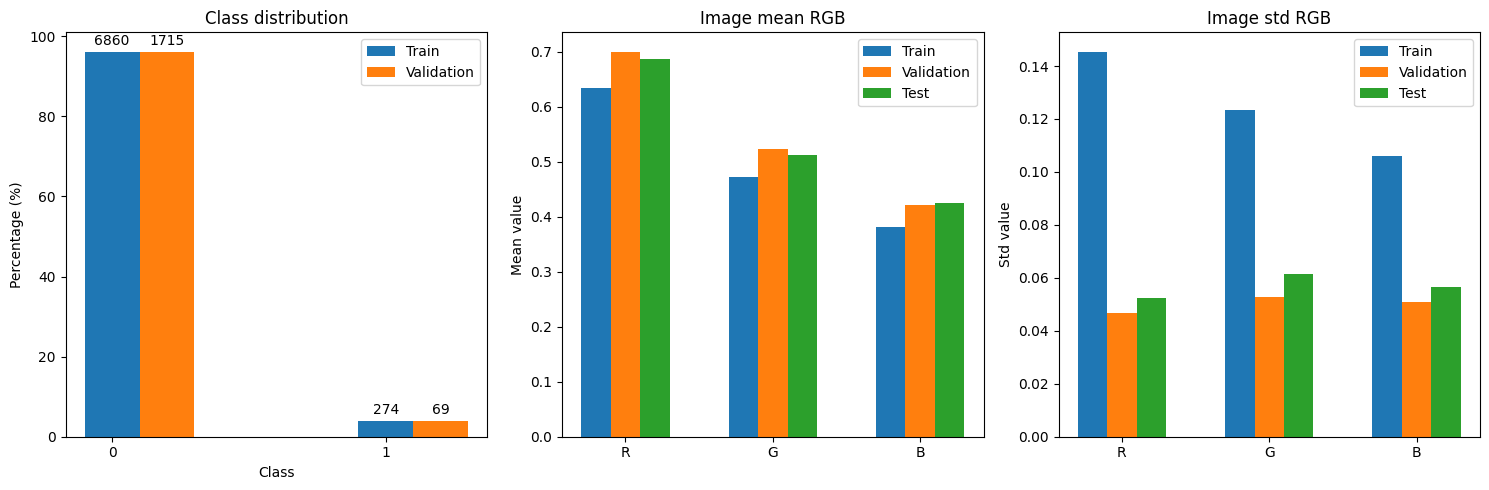

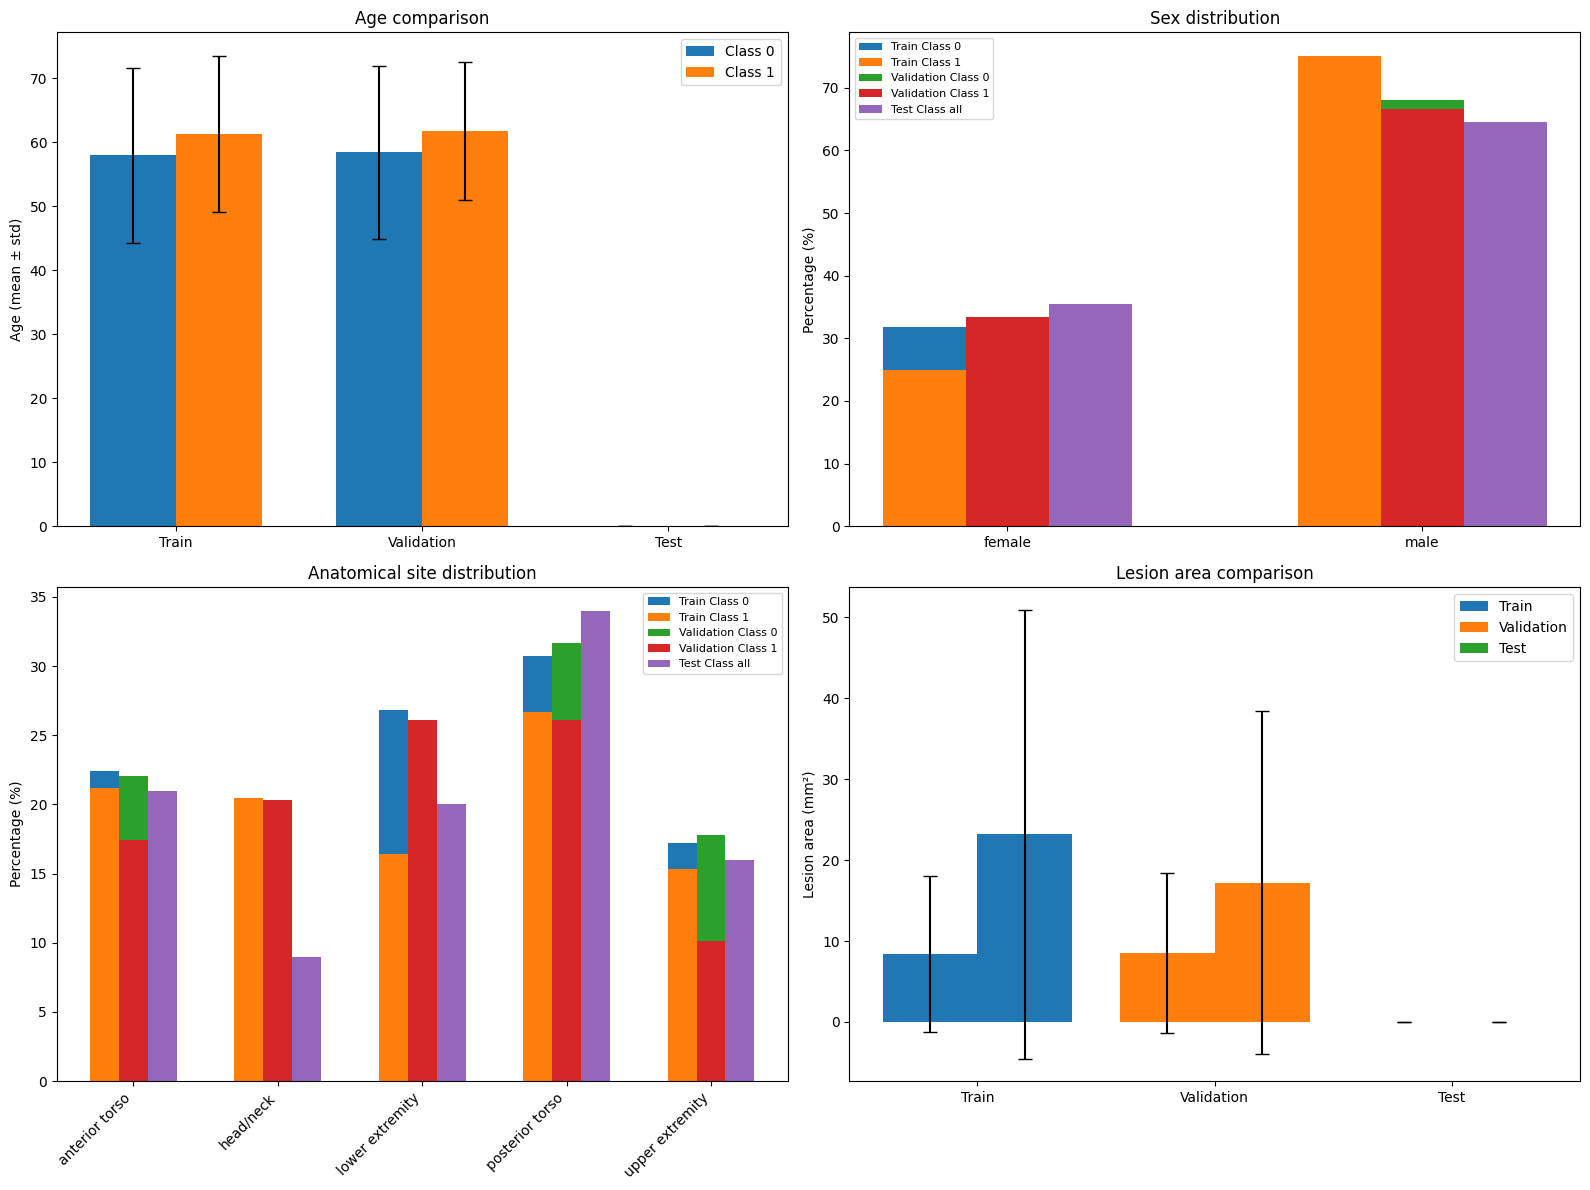

In [4]:
train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# Now we compare the analisis of the splits
plot_stats(stats_list)

## DataLoaders with balanced splits

We calculate the **ratio of the weighted sampler** using the formula:
$$
w_{c1}=\frac{p_{target}}{1-p_{target}}\frac{n_{c1}}{n_{c2}}
$$
so in the example we want $ p_{target} = 0.25 $
$$
w_{c1}=\frac{0.25}{0.75}\frac{20}{1}
$$

For the weights of the loss functions is as follows:
$$
pos_w=\frac{1-p_{posImg}}{p_{posImg}}
$$

In [5]:
# Get the weights for the sampler
multimodal_train_targets = train_dataset.metadata['target'].values
sample_weights = make_sampler_weights(
    multimodal_train_targets, 
    config.target_epoch_proportion)

# Create the weighted sampler with the calculated weights
multimodal_weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=config.num_imgs_epoch,
    replacement=True
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    sampler=multimodal_weighted_sampler,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")

📦 Multimodal data loaders created with balanced sampling!


# Backbone

In [6]:
class AttentionFusion(nn.Module):
    """
    Fusiona img_emb y meta_emb usando Multi-Head Attention real.
    Produce una predicción escalar (1 dimensión).
    """
    def __init__(self, dim, num_heads=4, num_classes=1):
        super().__init__()

        # Multi-Head Attention (Transformer) para fusionar ambos tokens
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=False)

        # Proyección del token fusionado
        self.fusion_proj = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim // 2, dim // 4),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Predicción escalar final
        self.out = nn.Linear(dim // 4, num_classes)

    def forward(self, img_emb, meta_emb):
        """
        img_emb:  (batch, dim)
        meta_emb: (batch, dim)
        returns: (batch, 1)
        """

        # Construimos tokens → secuencia de longitud 2
        tokens = torch.stack([img_emb, meta_emb], dim=0)  
        # tokens shape: (2, batch, dim)

        # Self-attention sobre los dos tokens
        attn_out, _ = self.attn(tokens, tokens, tokens)
        # attn_out shape: (2, batch, dim)

        # Fusion: agregamos ambos tokens
        fused = attn_out.mean(dim=0)  # (batch, dim)

        # Pasamos por MLP
        fused = self.fusion_proj(fused)

        # Predicción escalar
        pred = self.out(fused)

        return pred
    
class EmbeddingHead(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.net = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(input_dim, emb_dim),
        nn.BatchNorm1d(emb_dim),
        nn.GELU()
        )
    
    def forward(self, x):
        return self.net(x)

class MetaEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.BatchNorm1d(hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim//2, emb_dim)
        )
    def forward(self, x):
        return self.net(x)

class PretrainedClassifier(nn.Module):
    def __init__(self, device, model_name, model_origin, meta_dim,
                 num_classes=1, hidden_dim = 512):
        super().__init__()

        self.hidden_dim = hidden_dim

        # ----- Backbone for the image ------
        if model_origin == ".pt":
            self.backbone = torch.load(model_name)
            # change last layer
            self.backbone = remove_last_layer(self.backbone)

        elif model_origin == "timm":
            self.backbone = timm.create_model(
                model_name,
                pretrained=True,
                global_pool='avg',
                num_classes=0  # don't use the original detection head
            )

        # add a trainable head to the backbone
        self.backbone.to(device)
        self.device = device
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224).to(device)
            img_feat = self.backbone(dummy_img)
        self.img_dim = img_feat.shape[1]

        # freeze the backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.backbone_head = EmbeddingHead(self.img_dim, 
                                          self.hidden_dim//2).to(device)
        
        # ------ Metadata Model -------
        self.metadata_encoder = MetaEncoder(meta_dim, emb_dim=self.hidden_dim//2).to(device)

        # ------ Fusion with attention ------
        self.attention_fusion = AttentionFusion(dim=self.hidden_dim//2, 
                                                num_heads=4,
                                                num_classes=num_classes
                                                ).to(device)


    def forward(self, images, metadata):
        # ---- Image embedding ----
        backbone_img = self.backbone(images)
        img_emb = self.backbone_head(backbone_img)

        # ---- Metadata embedding ---
        meta_emb = self.metadata_encoder(metadata)

        #----- Attention fusion -----
        out = self.attention_fusion(img_emb, meta_emb)
        return out

class PretrainedClassifierExtended(PretrainedClassifier, TrainableModule):
    def __init__(self, device, model_name, model_origin, unfreeze_scheduler, meta_dim,
                 lr, criterion, val_freq=5, patience=5, min_delta=0.01):
        PretrainedClassifier.__init__(self, device, model_name, model_origin, meta_dim)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.name = model_name
        self.unfreeze_schedule = unfreeze_scheduler
        self.model_origin = model_origin
        self.val_freq = val_freq    # freq of validation metrics
        self.lr=lr
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):
        print(f"----------------------------------------")
        print(f"       Training {self.name}")
        print(f"----------------------------------------")

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            start = time.time()
            print(f"Epoch {epoch}/{epochs}: ", end="")

            for e, pct in self.unfreeze_schedule:
                if epoch == e:
                    self.unfreeze_backbone_layers(pct)
                    print(f"Descongelando {pct*100:.0f}% del backbone en epoch {epoch}")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos:.3f}%")

            if val_loader and epoch%self.val_freq==0:
                val_loss, val_auc = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")
            
            # 🧹 Clean epoch for VRAM
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

            
            print(f" in {time.time() - start:.2f}s")

    def unfreeze_backbone_layers(self, percent=0.2):
        layers = list(self.backbone.parameters())
        n_total = len(layers)
        n_unfreeze = int(n_total * percent)

        # unfreeze the last layers
        for p in layers[-n_unfreeze:]:
            p.requires_grad = True
    
    def load(self, path):
        state = torch.load(path, map_location=self.device, weights_only=True)
        self.load_state_dict(state)
        self.to(self.device)

### Train the mix models

📂 efficientnet_b0_pos0 loaded from memory


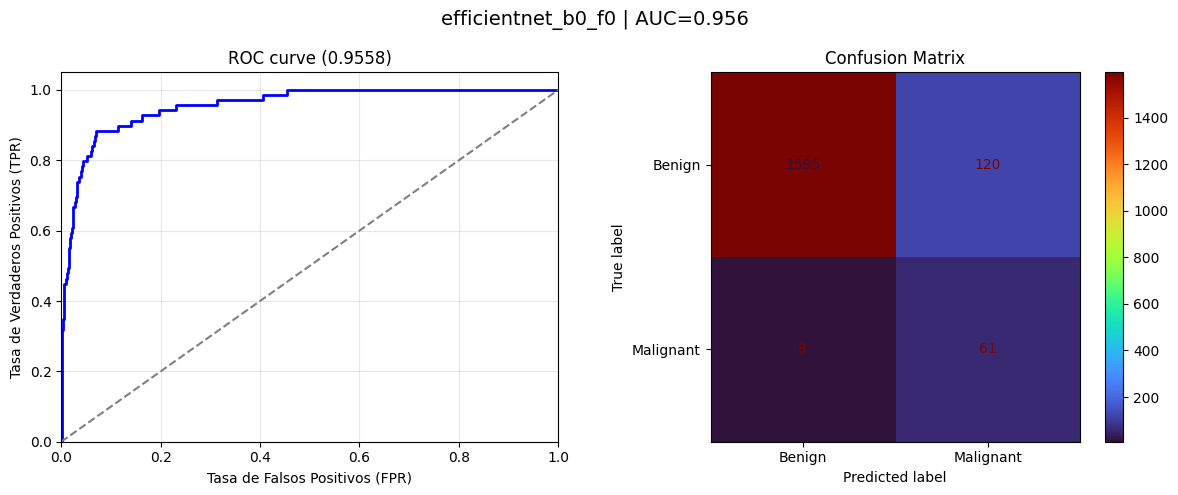

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 17.10it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0_pos0.csv
📂 efficientnet_b1_pos1 loaded from memory


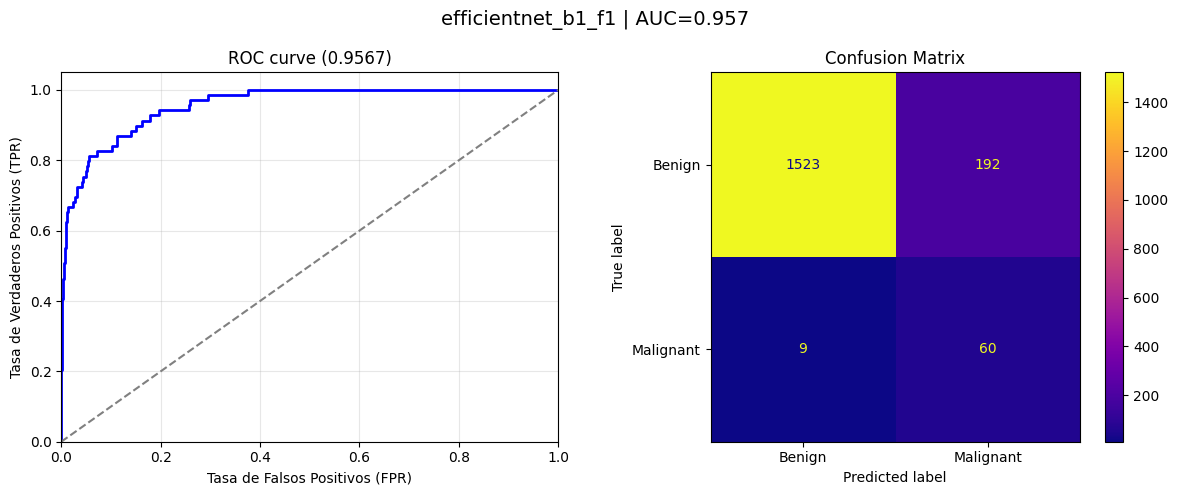

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 20.23it/s]


Saved submission with 100 rows to ../submission/efficientnet_b1_pos1.csv
📂 resnet50_pos2 loaded from memory


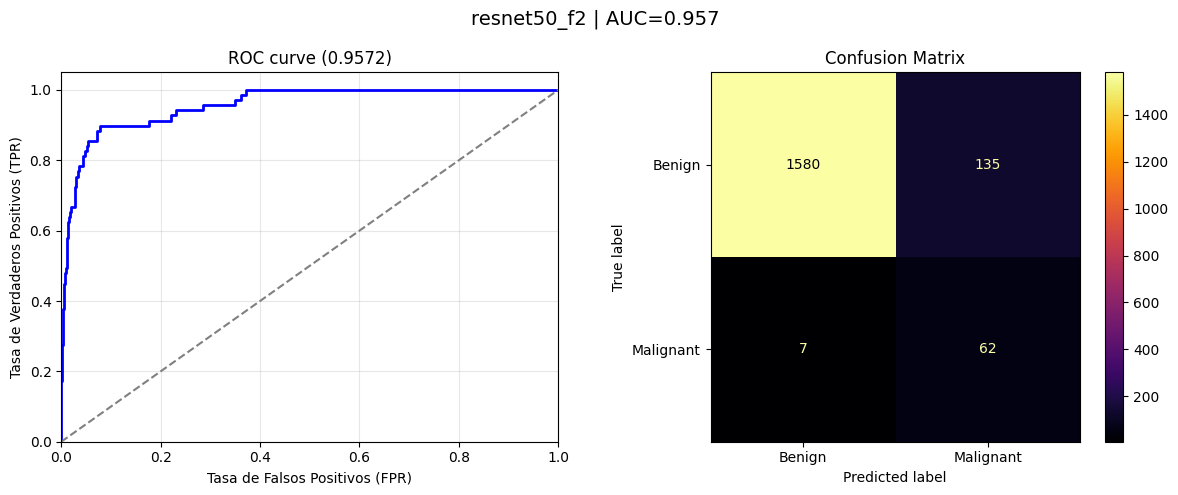

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 13.15it/s]


Saved submission with 100 rows to ../submission/resnet50_pos2.csv
📂 vgg16_pos3 loaded from memory


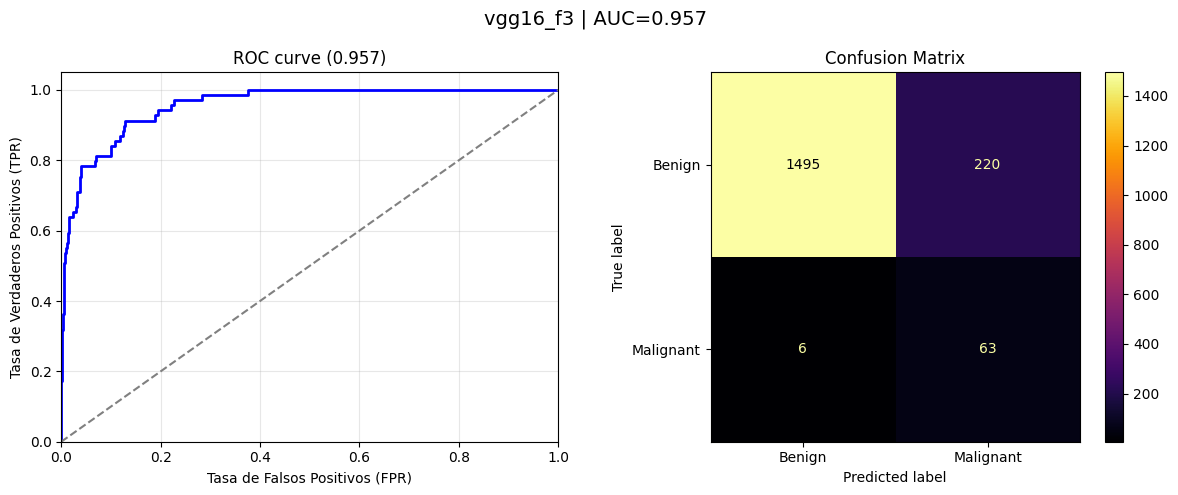

Inference on Test: 100%|██████████| 7/7 [00:00<00:00,  7.34it/s]


Saved submission with 100 rows to ../submission/vgg16_pos3.csv
📂 densenet121_pos4 loaded from memory


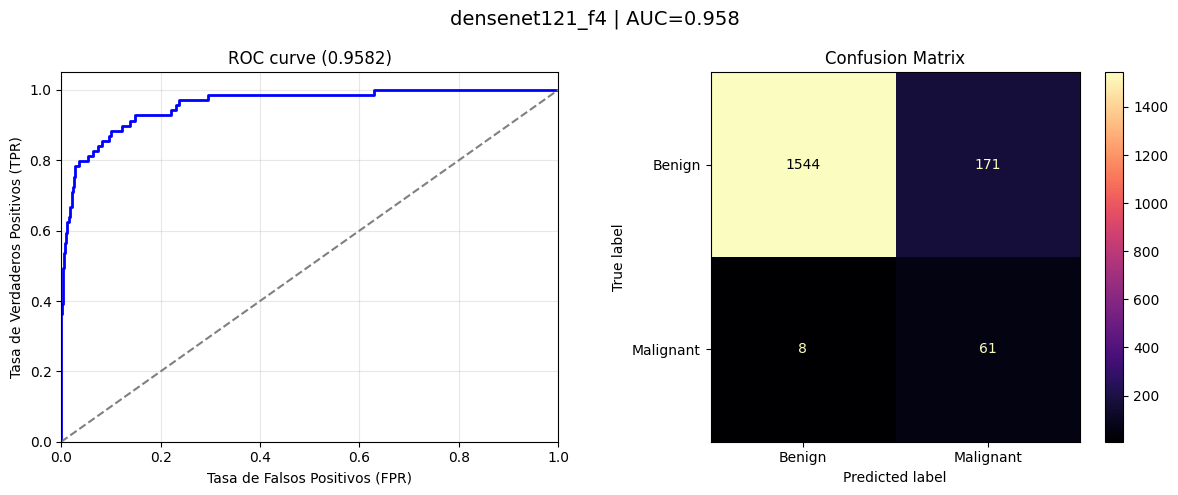

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 10.01it/s]

Saved submission with 100 rows to ../submission/densenet121_pos4.csv
💪 Ensemble weights:
	efficientnet_b0	19.97%
	efficientnet_b1	19.99%
	resnet50	20.00%
	vgg16	20.00%
	densenet121	20.03%


In [7]:
# Number of features coming from metadata
num_metadata_features = metadata_processor.transform(test_df).shape[1]

# -------------------------------------------------------------------------------
# 1º Define loss and model list
# -------------------------------------------------------------------------------
pos_weights = torch.tensor(config.BCE_loss_pos_weight).to(config.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# model names
# ["efficient_net_f0", "efficient_net_f1", "efficient_net_f2", "efficient_net_f3", "efficient_net_f4"]
model_paths = ["efficientnet_b0", "efficientnet_b1", "resnet50", "vgg16", "densenet121"]
model_orig = ["timm", "timm", "timm", "timm", "timm",
              "timm", "timm", "timm", "timm", "timm"]
model_types = ["mix", "mix", "mix", "mix", "mix",
               "mix", "mix", "mix", "mix", "mix",]

model_list = []     # for ensemble
oof_weights = []    # weights of each model based on oof predictions

# -------------------------------------------------------------------------------
# 2º Train / load ensemble models
# -------------------------------------------------------------------------------
for i, (model_name, model_orig) in enumerate(zip(model_paths, model_orig)):

    model_name_fold = f"{model_name}_pos{i}"
    save_path = f"{config.models_dir}/{model_name_fold}.pt"

    if model_name_fold + ".pt" not in os.listdir(config.models_dir):
        print(f"\n⏳ Training {model_name_fold} ...")

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features,
            unfreeze_scheduler=config.unfreeze_schedule,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq)

        model.fit(train_loader, valid_loader, epochs=config.fine_tuning_batch)
        model.save(save_path)

    else:

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features,
            unfreeze_scheduler=config.unfreeze_schedule,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq
        )
        model.load(save_path)
        print(f"📂 {model_name_fold} loaded from memory")

    # analize model and get its submission file
    labels, probs = model.pred_probs(valid_loader)
    plot_analisis(model.name, labels, probs, i)
    oof_weights.append(roc_auc_score(labels, probs))

    config.submission_dir.mkdir(parents=True, exist_ok=True)
    model.submit_kaggle(test_loader, 
                        submission_file=f"{config.submission_dir}/{model_name_fold}.csv")
    model_list.append(model)

# promediate the weights based in thir roc auc
oof_weights = np.array(oof_weights)
oof_weights = oof_weights / oof_weights.sum()
print("💪 Ensemble weights:")
for w, name in zip(oof_weights, model_paths):
    print(f"\t{name}\t{w*100:.2f}%")

### Now we use the trained models in an ensemble to give more generalization power

### Voting ensemble

In [16]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
import torch
import pickle
from tqdm import tqdm
import torch.nn as nn
import numpy as np


class LightGBMStackingEnsemble(nn.Module):
    def __init__(self, models, model_name, device):
        """
        models: lista de modelos PyTorch congelados
        """
        super().__init__()
        self.device = device
        self.name = model_name
        self.models = nn.ModuleList(models)
        self.best_model_AUC = 0

        # Freeze
        for m in self.models:
            m.eval()
            for p in m.parameters():
                p.requires_grad = False
            m.to(device)

        # LightGBM no trained
        self.lgbm_model = None

    def _extract_features(self, images, metadata=None):
        """Extrae logits de cada modelo → concatena features"""
        feats = []
        for m in self.models:
            if metadata is not None:
                logits = m(images, metadata)
            else:
                logits = m(images)
            feats.append(logits.detach().cpu().numpy())
        return np.concatenate(feats, axis=1)

    def fit_lightgbm(self, loader):
        """
        Extrae features desde los modelos PyTorch y entrena un LightGBM
        usando GridSearchCV para optimizar ROC-AUC.
        """

        # -------------------------
        # 1. EXTRAER FEATURES
        # -------------------------
        all_feats = []
        all_meta = []
        all_labels = []

        with torch.no_grad():
            for images, metadata, labels, _ in loader:
                images = images.to(self.device)
                metadata = metadata.to(self.device)

                feats = self._extract_features(images, metadata)
                all_feats.append(feats)
                all_meta.append(metadata.cpu().numpy())
                all_labels.append(labels.numpy())

        X_feats = np.concatenate(all_feats, axis=0)
        X_meta = np.concatenate(all_meta, axis=0)
        X = np.concatenate([X_feats, X_meta], axis=1)
        y = np.concatenate(all_labels, axis=0)

        print(f"[LightGBM] Training meta-model on features: {X.shape}")

        # -------------------------
        # 2. DEFINIR MODELO LGBM PARA SKLEARN
        # -------------------------
        lgbm_clf = lgb.LGBMClassifier(
            objective="binary",
            metric="auc",
            boosting_type="gbdt",
            n_estimators=500,
            n_jobs=-1,
            verbosity=-1
        )

        # -------------------------
        # 3. GRID DE HIPERPARÁMETROS
        # -------------------------
        param_grid = {
            "num_leaves": [64, 100],
            "subsample": [0.65, 0.9],
        }

        # -------------------------
        # 4. GRID SEARCH CV = ROC AUC
        # -------------------------
        print("[LightGBM] Running GridSearchCV...")

        grid = GridSearchCV(
            estimator=lgbm_clf,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=3,
            verbose=1,
            n_jobs=-1
        )

        grid.fit(X, y)

        print("\n==============================")
        print(" GridSearchCV terminado")
        print("==============================")
        print(f"Mejor ROC-AUC: {grid.best_score_:.5f}")
        print("Mejores parámetros:")
        for k, v in grid.best_params_.items():
            print(f"  {k}: {v}")

        # Guardar modelo final
        self.best_model_AUC = grid.best_score_
        self.lgbm_model = grid.best_estimator_
        print("\n[LightGBM] Meta-modelo final guardado en self.lgbm_model")

        
    def predict_proba(self, images, metadata):
        """Predicción final usando LightGBM"""
        with torch.no_grad():
            images = images.to(self.device)
            metadata = metadata.to(self.device)

            feats = self._extract_features(images, metadata)
            meta = metadata.cpu().numpy()

            X = np.concatenate([feats, meta], axis=1)
            preds = self.lgbm_model.predict(X)

        return preds

    def pred_probs(self, loader):
        final_preds = []
        final_labels = []

        with torch.no_grad():
            for images, metadata, labels, _ in loader:
                preds = self.predict_proba(images, metadata)
                final_preds.append(preds)
                final_labels.append(labels.numpy())

        return (np.concatenate(final_labels),
                np.concatenate(final_preds))
    
    def predict_logits(self, images, metadata):
        with torch.no_grad():
            images = images.to(self.device)
            metadata = metadata.to(self.device)

            feats = self._extract_features(images, metadata)
            meta = metadata.cpu().numpy()

            X = np.concatenate([feats, meta], axis=1)

            logits = self.lgbm_model.predict(X, raw_score=True)

        return logits

    
    def submit_kaggle(self, test_loader, submission_file="submission.csv"):
        """
        Generate Kaggle submission CSV using LightGBM stacked logits.
        """
        import pandas as pd

        self.eval()
        predictions = []

        with torch.no_grad():
            for images, metadata, isic_ids in tqdm(test_loader, desc="Inference on Test"):
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)

                # 1) Obtener logits desde LightGBM (raw_score=True)
                logits = self.predict_logits(images, metadata)

                # 2) Convertir logits → probabilidades
                probs = 1 / (1 + np.exp(-logits))   # sigmoide numpy

                # 3) Guardar resultados
                for isic_id, p in zip(isic_ids, probs):
                    predictions.append({"isic_id": isic_id, "target": float(p)})

        # Construir CSV
        submission_df = pd.DataFrame(predictions)
        submission_df = submission_df.sort_values(by="isic_id").reset_index(drop=True)
        submission_df.to_csv(submission_file, index=False)

        print(f"Saved submission with {len(submission_df)} rows to {submission_file}")
    
    # -------------------------------------------------------------
    def save(self, path):
        container = {
            "torch_state_dict": self.state_dict(),   # ONLY torch models
            "lgbm_model": pickle.dumps(self.lgbm_model),  # serialize LightGBM
            "best_auc": self.best_model_AUC
        }
        torch.save(container, path)
        print(f"Saved ensemble to {path}")
    
    def load(self, path, device='cpu'):
        container = torch.load(path, map_location=device)

        # 1. Load PyTorch models
        self.load_state_dict(container["torch_state_dict"])
        self.to(device)

        # 2. Load LightGBM model
        self.lgbm_model = pickle.loads(container["lgbm_model"])

        # 3. Restore AUC
        self.best_model_AUC = container.get("best_auc", 0)

        self.eval()
        print(f"Loaded ensemble with AUC={self.best_model_AUC}")


# Train Ensemble


/tmp/ipykernel_4311/750499769.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  container = torch.load(path, map_location=device)


Loaded ensemble with AUC=0.9612140061770763


/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have va

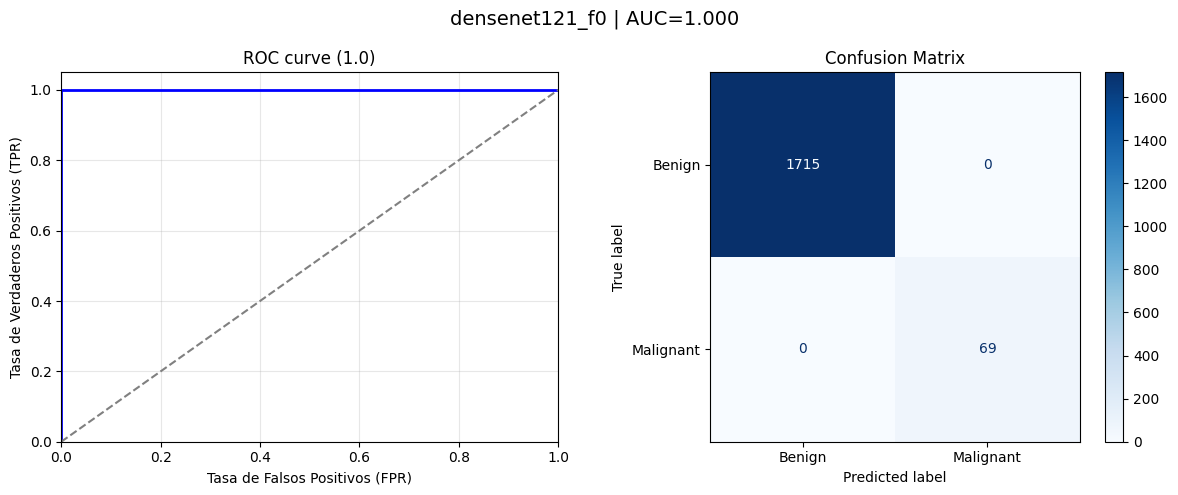

Inference on Test:   0%|          | 0/7 [00:00<?, ?it/s]/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Inference on Test:  14%|█▍        | 1/7 [00:00<00:02,  2.34it/s]/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Inference on Test:  29%|██▊       | 2/7 [00:00<00:01,  3.45it/s]/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Inference on Test:  43%|████▎     | 3/7 [00:00<00:00,  4.08it/s]/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: 

Saved submission with 100 rows to ../submission/stacking_lgbm.csv


In [17]:
ensemble_name = "stacking_lgbm"
ensemble_path = config.models_dir / f"{ensemble_name}.pt"

if ensemble_name + ".pt" not in os.listdir(config.models_dir):
    # train ensemble
    ensemble = LightGBMStackingEnsemble(model_list, 
                                    ensemble_name,
                                    device=config.device)
    ensemble.fit_lightgbm(valid_loader)
    
    ensemble.save(ensemble_path)

else:   # load from memory
    ensemble = LightGBMStackingEnsemble(model_list, 
                                    ensemble_name,
                                    device=config.device)
    ensemble.load(ensemble_path, device=config.device)

# analize result
labels, probs = ensemble.pred_probs(valid_loader)
plot_analisis(model_name, labels, probs)

ensemble.submit_kaggle(test_loader, 
                            submission_file=f"{config.submission_dir}/stacking_lgbm.csv")